<a href="https://colab.research.google.com/github/mdrehantabish123/mdrehantabish123-Data_Science_Lab_SE_A_38/blob/main/Experiment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Import Required Libraries

We begin by importing all the necessary libraries for data manipulation, visualization, and machine learning. This includes `numpy` for numerical operations, `pandas` for data handling, `matplotlib.pyplot` and `seaborn` for plotting, and `sklearn` for machine learning tools.

In [34]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set plot style for better aesthetics
sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


### 2. Load Dataset

Next, we load the `HousingData.csv` dataset into a pandas DataFrame. This dataset contains various features of houses in Boston and their corresponding median values (MEDV).

In [35]:
# Load the dataset
df = pd.read_csv('/content/HousingData.csv')

print("Dataset loaded successfully.")

Dataset loaded successfully.


### 3. Display Basic Information

It's crucial to understand the basic structure and content of our dataset. We'll display the first few rows, its shape (number of rows and columns), column names, a summary of data types and non-null values, and descriptive statistics.

In [36]:
print("\nFirst 5 rows of the dataset:")
display(df.head())

print(f"\nDataset shape: {df.shape}")

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nDescriptive statistics:")
display(df.describe())


First 5 rows of the dataset:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2



Dataset shape: (506, 14)

Column names:
['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB

Descriptive statistics:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


### 4. Data Preprocessing

Data preprocessing involves cleaning the dataset to ensure it's suitable for model training. We will check for missing values and handle them by filling with the mean of their respective columns. We'll also check for and remove any duplicate rows.

In [37]:
# Check for missing values before handling
print("Missing values before handling:\n", df.isnull().sum())

# Handle missing values by filling with the mean of each column
df = df.fillna(df.mean())

# Check for missing values after handling
print("\nMissing values after handling:\n", df.isnull().sum())

# Check for duplicate rows
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
final_rows = df.shape[0]

if initial_rows > final_rows:
    print(f"\n{initial_rows - final_rows} duplicate rows removed.")
else:
    print("\nNo duplicate rows found.")

print(f"Dataset shape after preprocessing: {df.shape}")

Missing values before handling:
 CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

Missing values after handling:
 CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

No duplicate rows found.
Dataset shape after preprocessing: (506, 14)


### 5. Exploratory Data Analysis (EDA)

EDA helps us understand the relationships between features and the target variable. We'll visualize correlations using a heatmap and observe individual feature relationships with the target using scatter plots. A pairplot will provide a holistic view of relationships among key features.

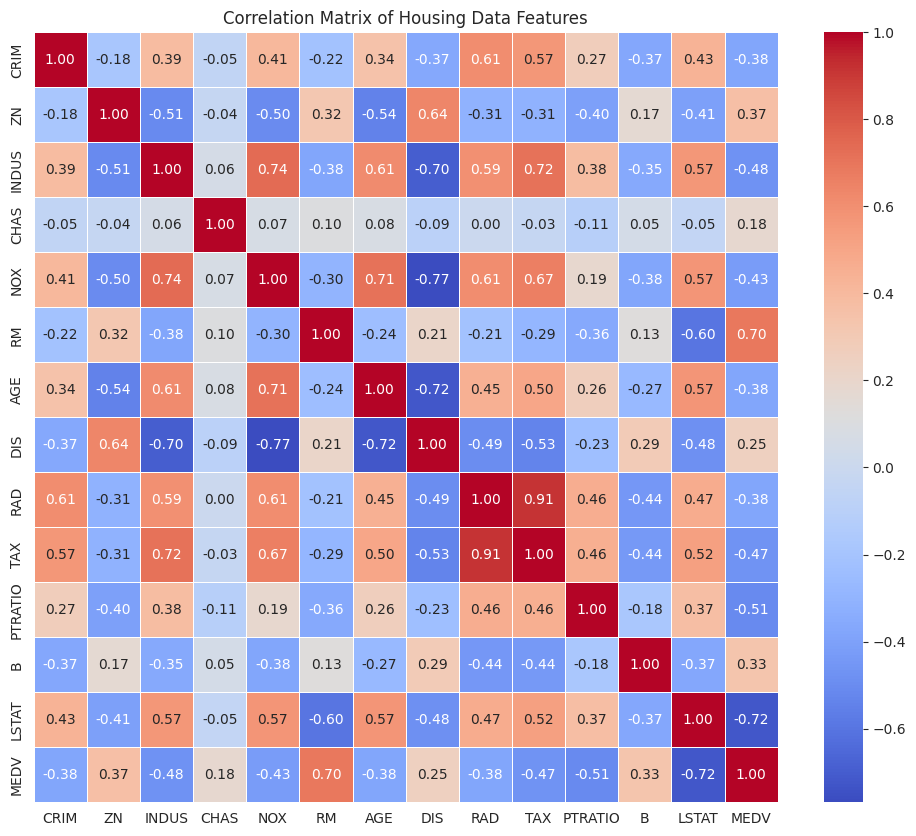

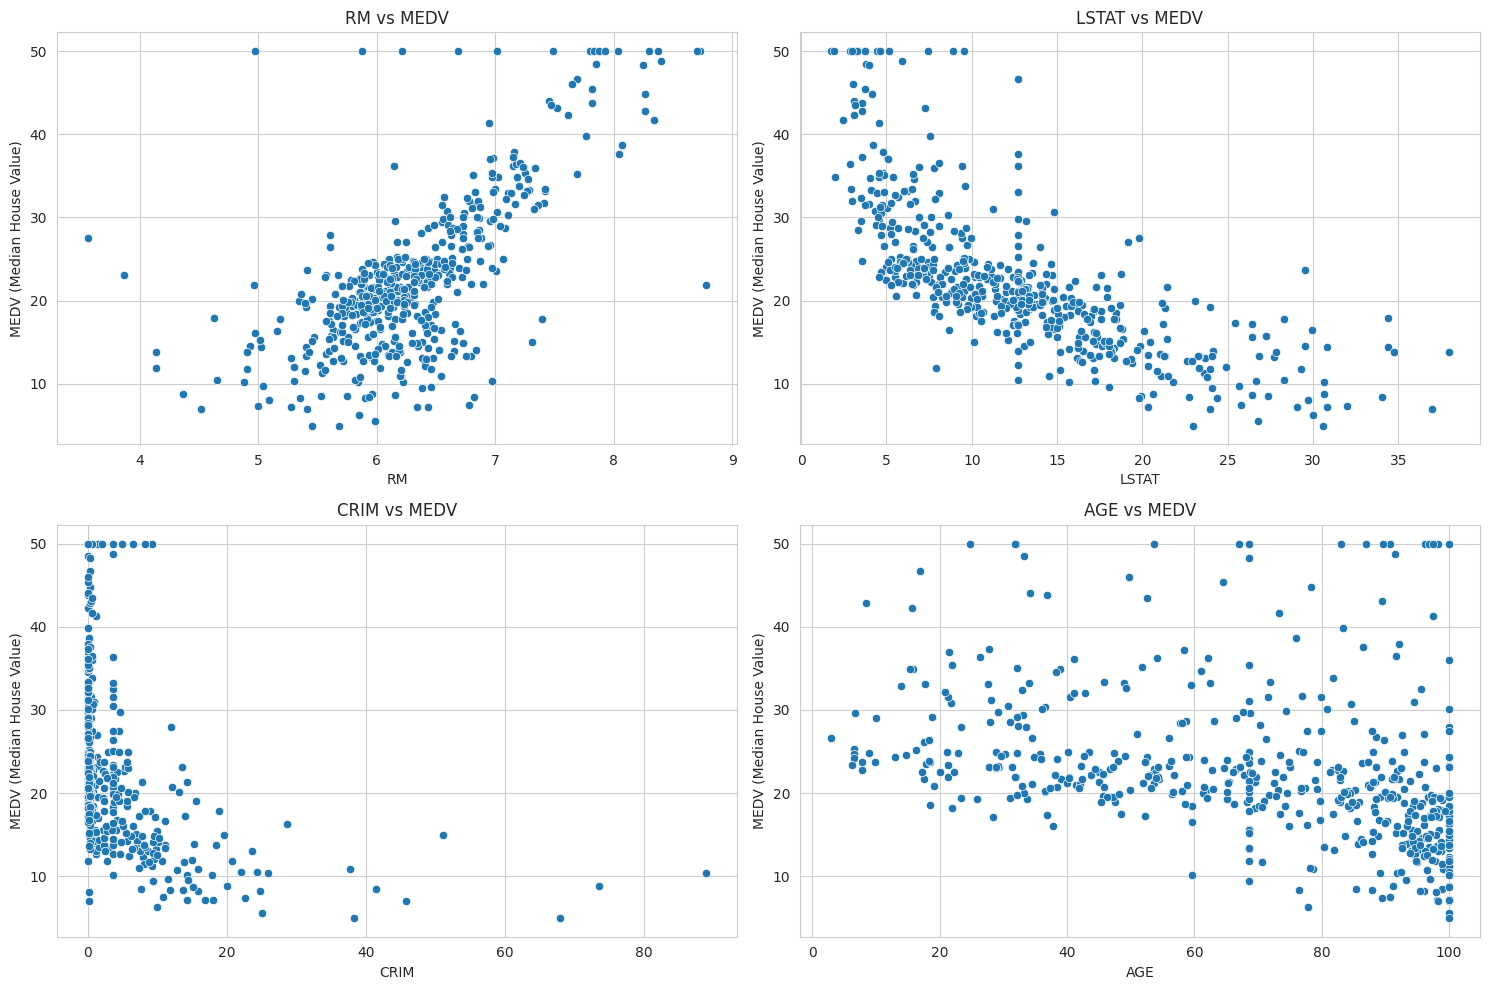

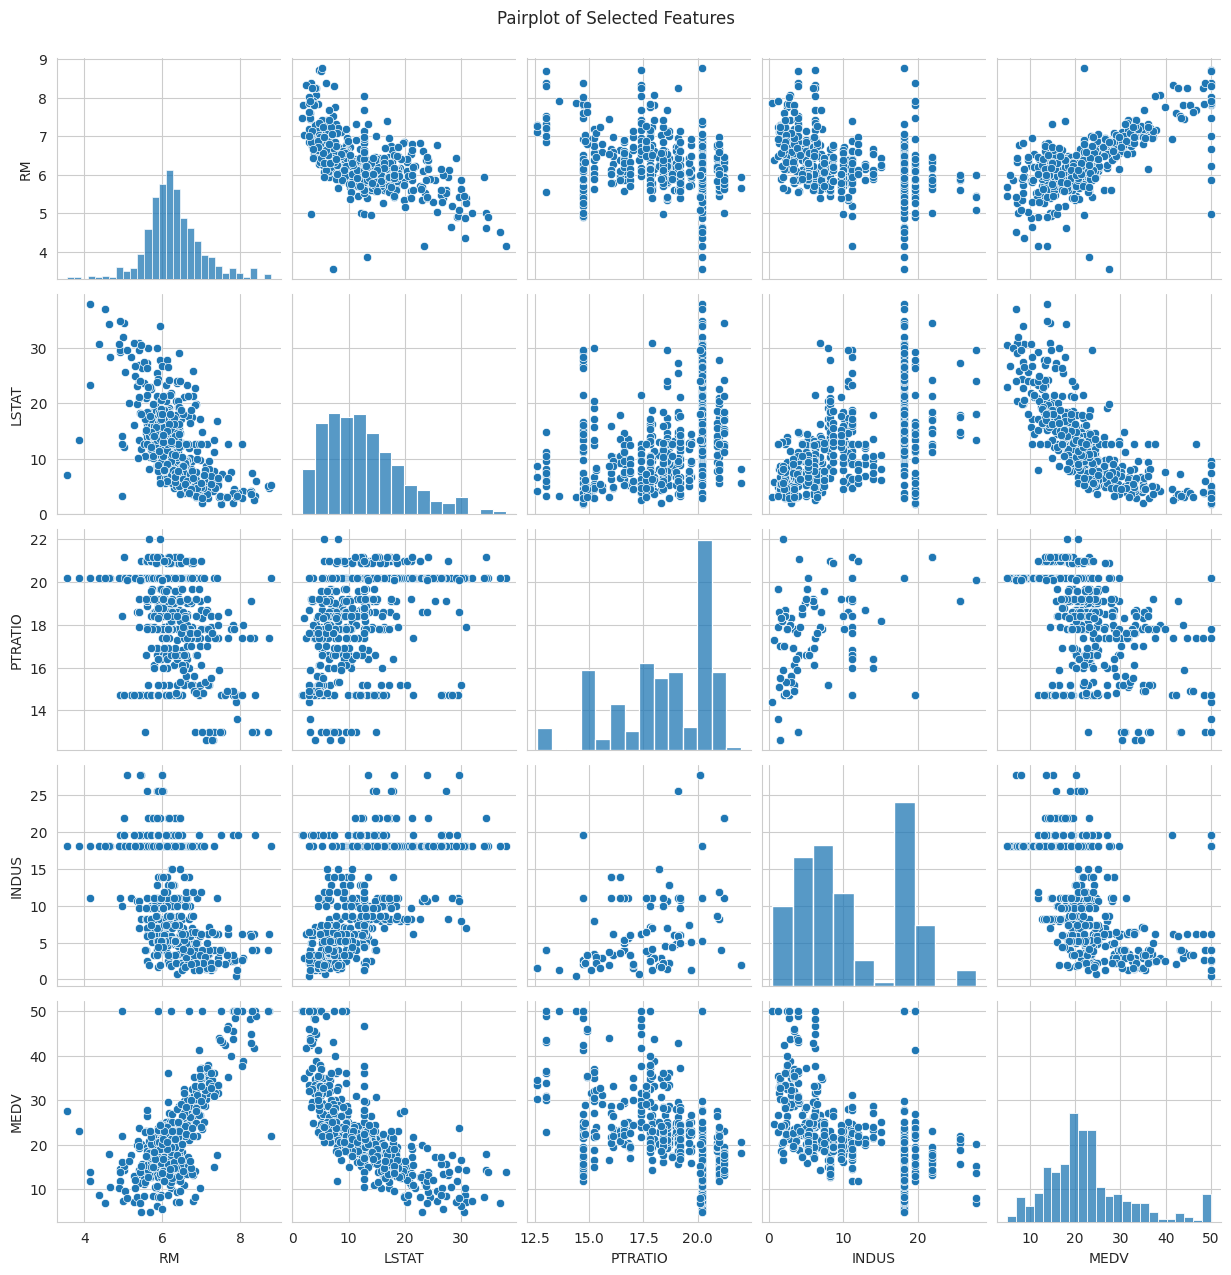

In [38]:
# Correlation Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Housing Data Features')
plt.show()

# Scatter plots for important features vs MEDV
features_to_plot = ['RM', 'LSTAT', 'CRIM', 'AGE']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(features_to_plot):
    plt.subplot(2, 2, i + 1) # 2 rows, 2 columns
    sns.scatterplot(x=feature, y='MEDV', data=df)
    plt.title(f'{feature} vs MEDV')
    plt.xlabel(feature)
    plt.ylabel('MEDV (Median House Value)')
plt.tight_layout()
plt.show()

# Pairplot for selected important features and MEDV
# Select a subset of features for the pairplot for better readability
selected_features_for_pairplot = ['RM', 'LSTAT', 'PTRATIO', 'INDUS', 'MEDV']
sns.pairplot(df[selected_features_for_pairplot])
plt.suptitle('Pairplot of Selected Features', y=1.02) # Adjust suptitle position
plt.show()

### 6. Define Features (X) and Target (y)

We separate the dataset into features (independent variables, `X`) and the target variable (dependent variable, `y`). In this case, `MEDV` is our target, and all other columns are features.

In [39]:
# Features (X) - all columns except 'MEDV'
X = df.drop('MEDV', axis=1)

# Target (y) - 'MEDV' column
y = df['MEDV']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print("\nFirst 5 rows of Features (X):")
display(X.head())
print("\nFirst 5 rows of Target (y):")
display(y.head())

Features (X) shape: (506, 13)
Target (y) shape: (506,)

First 5 rows of Features (X):


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.980000
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.140000
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.030000
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.940000
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,12.715432



First 5 rows of Target (y):


,MEDV
0,24.0
1,21.6
2,34.7
3,33.4
4,36.2


### 7. Split Dataset into Training and Testing Sets

To evaluate our model's generalization ability, we split the dataset into training and testing sets. An 80-20 split is commonly used, where 80% of the data is for training and 20% for testing. `random_state` ensures reproducibility.

In [40]:
# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (404, 13)
X_test shape: (102, 13)
y_train shape: (404,)
y_test shape: (102,)


### 8. Train Linear Regression Model

We initialize a Linear Regression model and train it using the training data (`X_train`, `y_train`). The model learns the coefficients that best fit the linear relationship between the features and the target.

In [41]:
# Initialize the Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### 9. Predict Values on Test Data

After training, we use the model to make predictions on the unseen test data (`X_test`). These predictions (`y_pred`) will be compared against the actual test target values (`y_test`) to evaluate the model's performance.

In [42]:
# Predict house prices using the test data
y_pred = model.predict(X_test)

print("Predictions made on test data.")
print("\nFirst 10 predicted values:")
print(y_pred[:10])

Predictions made on test data.

First 10 predicted values:
[29.14324958 36.53566752 14.49251294 25.08111038 18.45609233 23.01049373
 18.13868607 14.62651674 22.1158938  20.87063644]


### 10. Evaluate Model

Model evaluation involves calculating various metrics to quantify how well our model performs. We will use Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared (R²).

In [43]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Evaluation Results:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

Evaluation Results:
Mean Absolute Error (MAE): 3.15
Mean Squared Error (MSE): 25.02
Root Mean Squared Error (RMSE): 5.00
R-squared (R²): 0.66


### 11. Visualization: Actual vs. Predicted Values

To visually assess the model's performance, we'll plot the actual house prices against the predicted house prices. A good model would show points close to the diagonal line (where actual equals predicted).

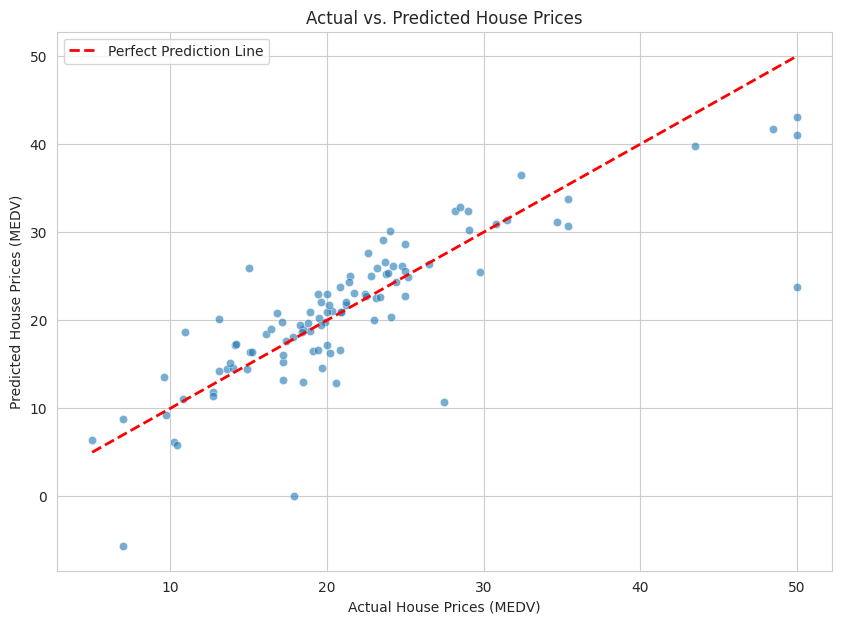

In [44]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction Line')
plt.title('Actual vs. Predicted House Prices')
plt.xlabel('Actual House Prices (MEDV)')
plt.ylabel('Predicted House Prices (MEDV)')
plt.legend()
plt.grid(True)
plt.show()

### 12. Print Model Coefficients and Intercept

The coefficients indicate the weight or importance of each feature in predicting the target variable, while the intercept represents the predicted target value when all features are zero.

In [45]:
print("\nModel Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.4f}")

print(f"\nModel Intercept: {model.intercept_:.4f}")


Model Coefficients:
  CRIM: -0.1141
  ZN: 0.0290
  INDUS: -0.0271
  CHAS: 3.2407
  NOX: -16.0175
  RM: 4.7524
  AGE: -0.0195
  DIS: -1.5216
  RAD: 0.2228
  TAX: -0.0092
  PTRATIO: -0.8860
  B: 0.0123
  LSTAT: -0.4384

Model Intercept: 27.9125


### 13. Conclusion

The Linear Regression model effectively predicts house prices with an R-squared value of **0.66**, indicating that approximately 66% of the variance in house prices can be explained by the features. The Mean Absolute Error (MAE) of **3.15** and Root Mean Squared Error (RMSE) of **5.00** suggest that, on average, the model's predictions are within approximately $3,150 and $5,000 (assuming MEDV is in thousands of dollars) of the actual prices. This performance indicates a reasonably good fit for the dataset, making the model suitable for this regression task. The coefficients provide insights into the relative impact of each feature on house prices.